# Notebook 3: Credit Market Regime Detection via Hidden Markov Models

In notebook 2 we demonstrated that the relationship between credit spreads and market risk factors is not stable over time. Factor sensitivities, particularly for NFCI and the yield curve slope, varied substantially in both magnitude and direction across different market environments. This finding motivates a framework that explicitly accounts for discrete shifts in market dynamics.

A simple threshold-based approach is insufficient for credit regime identification because market stress is multidimensional and evolves continuously across several 
risk indicators simultaneously. Credit spreads, equity volatility, financial conditions, and yield curve shape often move asynchronously, making stable deterministic thresholds difficult to define. In addition, threshold methods impose abrupt regime boundaries and ignore transition dynamics. In practice, credit markets typically evolve gradually between risk-on, tightening, stress, and normalization regimes.

Hidden Markov Models provide a more flexible framework by treating market regimes as latent probabilistic states inferred jointly from multiple observed variables. This allows regime classification to adapt dynamically over time while explicitly modeling persistence and transition probabilities between regimes.

The central hypothesis of this notebook is that credit markets operate in a small number of distinct regimes, each characterized by a different combination of spread levels, volatility, and factor sensitivities. Identifying these regimes in real time is a core task for a credit market risk desk. These regimes determines how spread movements should be interpreted, what stress scenarios are relevant, and how sensitive CVA estimates are to current market conditions.

## Hidden Markov Models

A Hidden Markov Model (HMM) is a statistical framework for modeling time series data that is assumed to be generated by an unobserved, hidden process switching between a finite number of states. The model has two core components:
- **Hidden States**: At each time $t$, the market is assumed to be in one of $K$ discrete regimes $S_t \in \{1, 2, ..., K\}$. These states are not directly observable, and instead they must be inferred from the data.
- **Observations**: At each time $t$, we observe a vector of market variables $x_t$ (e.g. OAS level, VIX, NFCI). These observations are assumed to be drawn from a state-dependent distribution:

$$\mathbf{x}_t \mid S_t = k \sim \mathcal{N}(\boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k)$$


Regime switches follow a first-order Markov process, governed by a transition probability matrix $P$:

$$P_{ij} = P(S_{t+1} = j \mid S_t = i)$$

$P_{ij}$ represents the probability of transitioning from regime $i$ to regime $j$ on any given day. High diagonal values indicate persistent regimes; low diagonal values indicate frequent switching.

The model is estimated via the Expectation-Maximization (EM) algorithm, which iteratively optimizes the model parameters to maximize the likelihood of the observed data. The Viterbi algorithm is then used to decode the most likely sequence of hidden states given the fitted model.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Load datasets
df = pd.read_csv('../data/processed/main_dataset.csv', index_col='date', parse_dates=True)

decomposed = pd.read_csv(
    '../data/processed/decomposed_spreads.csv', index_col='date', parse_dates=True
)

## Feature Engineering

Recall that We have constructed a set of features that capture the key dimensions of credit market conditions identified in Notebook 2:

- **IG OAS level**: the primary credit spread indicator
- **IG OAS daily change**: captures spread momentum and day-to-day volatility
- **HY - IG spread**: risk appetite indicator, measures the premium demanded to cross from investment grade into high yield
- **VIX**: equity market volatility and broad risk aversion
- **T10Y2Y**: yield curve slope, captures macro rate environment
- **NFCI**: overall financial conditions

These six features collectively capture spread levels, spread dynamics, risk appetite, equity volatility, and macro conditions.

All features are standardized to zero mean and unit variance before fitting the HMM. Standardization ensures that no single feature dominates the model due to scale differences rather than genuine information content.

In [5]:
features = pd.DataFrame(index=df.index)

features['ig_oas'] = df['ig_oas']
features['ig_oas_change'] = df['ig_oas'].diff()
features['hy_ig_spread'] = df['hy_oas'] - df['ig_oas']
features['vix'] = df['vix']
features['t10y2y'] = df['t10y2y']
features['nfci'] = df['nfci']

# Drop first row (NaN from diff)
features = features.dropna()

print(f"\nFeature summary:")
print(features.describe().round(3))

# Standardize
scaler = StandardScaler()
X = scaler.fit_transform(features)

print(f"\nStandardized matrix shape: {X.shape}")
print(f"Mean: {X.mean(axis=0).round(4)}")
print(f"Std: {X.std(axis=0).round(4)}")


Feature summary:
         ig_oas  ig_oas_change  hy_ig_spread       vix    t10y2y      nfci
count  1325.000       1325.000      1325.000  1325.000  1325.000  1325.000
mean    107.149         -0.011       250.818    19.172     0.106    -0.407
std      26.001          1.677        47.996     5.266     0.592     0.145
min      73.000        -10.000       178.000    11.860    -1.080    -0.694
25%      86.000         -1.000       216.000    15.430    -0.390    -0.513
50%      96.000          0.000       233.000    17.890     0.150    -0.417
75%     129.000          1.000       281.000    21.670     0.550    -0.300
max     171.000         14.000       432.000    52.330     1.470    -0.100

Standardized matrix shape: (1325, 6)
Mean: [ 0.  0.  0.  0. -0.  0.]
Std: [1. 1. 1. 1. 1. 1.]


## Model Selection — Number of States

Before fitting the HMM, we need to determine the optimal number of hidden states K. We fit models with K = 2, 3, 4, and 5 states and compare them using two 
information criteria:
- **AIC (Akaike Information Criterion)**: penalizes model complexity, favors parsimony;
- **BIC (Bayesian Information Criterion)**: applies a stronger penalty for additional parameters, generally preferred for model selection in time series.

K=2: LogLik=-5254.6  Params=57  AIC=10623.3  BIC=10919.1
K=3: LogLik=-4313.9  Params=89  AIC=8805.9  BIC=9267.7
K=4: LogLik=-3456.6  Params=123  AIC=7159.1  BIC=7797.4
K=5: LogLik=-2548.4  Params=159  AIC=5414.8  BIC=6239.9
K=6: LogLik=-3013.2  Params=197  AIC=6420.5  BIC=7442.7


Model is not converging.  Current: -1619.3794933855088 is not greater than -1619.377975215251. Delta is -0.0015181702578956902


K=7: LogLik=-1619.4  Params=237  AIC=3712.8  BIC=4942.6


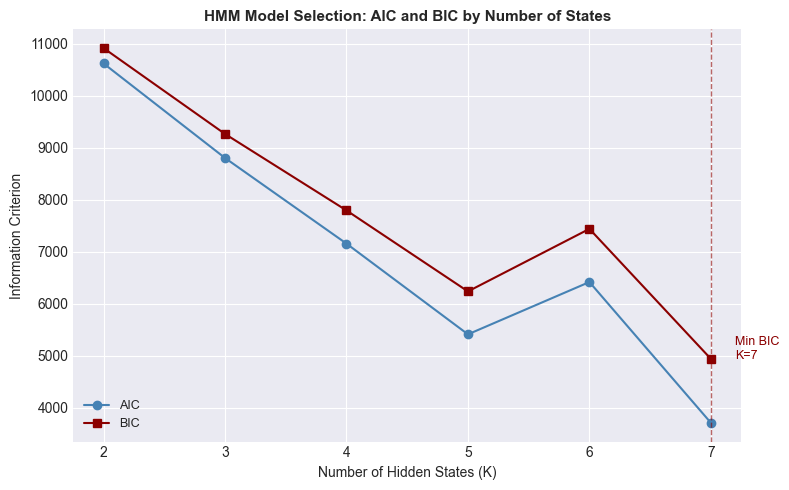

In [14]:
from sklearn.model_selection import train_test_split

n_states_range = [2, 3, 4, 5, 6, 7]
n_iter = 1000
random_state = 42

results_selection = []

for n_states in n_states_range:
    model = GaussianHMM(
        n_components=n_states,
        covariance_type='full',
        n_iter=n_iter,
        random_state=random_state
    )
    model.fit(X)

    n_features = X.shape[1]

    n_params = ((n_states - 1) + n_states * (n_states - 1) + n_states * n_features + n_states * n_features * (n_features + 1) // 2)

    log_like = model.score(X)
    aic = -2 * log_like + 2 * n_params
    bic = -2 * log_like + np.log(len(X)) * n_params

    results_selection.append({
        'n_states': n_states,
        'log_like': log_like,
        'n_params': n_params,
        'aic': aic,
        'bic': bic,
    })

    print(f"K={n_states}: "
          f"LogLik={log_like:.1f}  "
          f"Params={n_params}  "
          f"AIC={aic:.1f}  "
          f"BIC={bic:.1f}")

results_df = pd.DataFrame(results_selection)

# Plot AIC and BIC
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(results_df['n_states'], results_df['aic'], marker='o', color='steelblue', linewidth=1.5, label='AIC')
ax.plot(results_df['n_states'], results_df['bic'], marker='s', color='darkred', linewidth=1.5, label='BIC')

# Mark minimum BIC
best_k = results_df.loc[results_df['bic'].idxmin(), 'n_states']
best_bic = results_df['bic'].min()
ax.axvline(x=best_k, color='darkred', linestyle='--', linewidth=1.0, alpha=0.6)
ax.annotate(f'Min BIC\nK={best_k}', xy=(best_k, best_bic), xytext=(best_k + 0.2, best_bic * 1.001), fontsize=9, color='darkred')

ax.set_xlabel('Number of Hidden States (K)')
ax.set_ylabel('Information Criterion')
ax.set_title('HMM Model Selection: AIC and BIC by Number of States', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.set_xticks(n_states_range)

plt.tight_layout()
plt.savefig('../data/processed/03_model_selection.png', dpi=150, bbox_inches='tight')
plt.show()

Both AIC and BIC criteria decline substantially as the number of states increases, reflecting improved in-sample fit from greater model flexibility. However, the K=6 and K=7 models exhibit convergence instability and economically implausible regime behavior. In particular, higher-state specifications generate extremely short-lived regimes with average durations of only a few trading days, suggesting that the model is fragmenting short-term noise rather than identifying persistent credit market states. Therefore, K=6 and K=7 are excluded despite their lower information criteria, and subsequent analysis focuses on more parsimonious and economically interpretable specifications.

Statistical criteria indicate K=5 as the minimum BIC before convergence issues emerge. However, BIC alone is insufficient for selecting the number of regimes in a financial application considering statistically optimal model may produce economically meaningless or unstable regime assignments.

We then evaluate K=4 and K=5 across four practical criteria:

- **State occupancy**: number of days assigned to each state — states with very few observations are likely spurious;
- **Regime persistence**: diagonal elements of the transition probability matrix (low diagonal values indicate unstable, short-lived regimes);
- **Average Duration**: expected number of consecutive days in each state, computed as $1/(1 - P_{ii})$;
- **State means**: average feature values in each state to make sure states must be economically distinguishable to be meaningful.

In [16]:
def evaluate_hmm(X, n_states, features_df, random_state=42, n_iter=1000):
    """
    Fit HMM and return diagnostic statistics.
    """
    model = GaussianHMM(
        n_components=n_states,
        covariance_type='full',
        n_iter=n_iter,
        random_state=random_state
    )
    model.fit(X)
    states = model.predict(X)

    # State occupancy
    occupancy = pd.Series(states).value_counts().sort_index()
    occupancy_pct = (occupancy / len(states) * 100).round(1)

    # Transition matrix
    trans = pd.DataFrame(
        model.transmat_,
        index=[f'State {i}' for i in range(n_states)],
        columns=[f'State {i}' for i in range(n_states)]
    ).round(4)

    # Average duration
    diag = np.diag(model.transmat_)
    avg_duration = (1 / (1 - diag)).round(1)

    # State means (unstandardized)
    means_std = pd.DataFrame(
        model.means_,
        columns=features_df.columns,
        index=[f'State {i}' for i in range(n_states)]
    ).round(3)

    # Inverse transform to original scale
    means_orig = pd.DataFrame(
        scaler.inverse_transform(model.means_),
        columns=features_df.columns,
        index=[f'State {i}' for i in range(n_states)]
    ).round(2)

    return {
        'model': model,
        'states': states,
        'occupancy': occupancy,
        'occupancy_pct': occupancy_pct,
        'trans': trans,
        'avg_duration': avg_duration,
        'means_orig': means_orig,
    }

# Evaluate K=4 and K=5
eval4 = evaluate_hmm(X, 4, features)
eval5 = evaluate_hmm(X, 5, features)

# K=4 diagnostics
print("=" * 60)
print("K = 4 DIAGNOSTICS")
print("=" * 60)

print("\nState Occupancy:")
for i in range(4):
    days = eval4['occupancy'].get(i, 0)
    pct  = eval4['occupancy_pct'].get(i, 0)
    dur  = eval4['avg_duration'][i]
    flag = " ← FRAGMENTED" if days < 50 else ""
    print(f"  State {i}: {days:4d} days "
          f"({pct:5.1f}%)  "
          f"avg duration: {dur:5.1f} days{flag}")

print("\nTransition Matrix (diagonal = persistence):")
print(eval4['trans'].to_string())

print("\nState Means (original scale):")
print(eval4['means_orig'].to_string())

# K=5 diagnostics
print("\n" + "=" * 60)
print("K = 5 DIAGNOSTICS")
print("=" * 60)

print("\nState Occupancy:")
for i in range(5):
    days = eval5['occupancy'].get(i, 0)
    pct  = eval5['occupancy_pct'].get(i, 0)
    dur  = eval5['avg_duration'][i]
    flag = " ← FRAGMENTED" if days < 50 else ""
    print(f"  State {i}: {days:4d} days "
          f"({pct:5.1f}%)  "
          f"avg duration: {dur:5.1f} days{flag}")

print("\nTransition Matrix (diagonal = persistence):")
print(eval5['trans'].to_string())

print("\nState Means (original scale):")
print(eval5['means_orig'].to_string())

K = 4 DIAGNOSTICS

State Occupancy:
  State 0:  209 days ( 15.8%)  avg duration:  39.8 days
  State 1:  393 days ( 29.7%)  avg duration: 122.5 days
  State 2:  422 days ( 31.8%)  avg duration: 102.3 days
  State 3:  301 days ( 22.7%)  avg duration: 101.1 days

Transition Matrix (diagonal = persistence):
         State 0  State 1  State 2  State 3
State 0   0.9748   0.0152   0.0052   0.0048
State 1   0.0082   0.9918   0.0000   0.0000
State 2   0.0050   0.0000   0.9902   0.0048
State 3   0.0000   0.0000   0.0099   0.9901

State Means (original scale):
         ig_oas  ig_oas_change  hy_ig_spread    vix  t10y2y  nfci
State 0  114.01           0.29        253.57  26.01    0.40 -0.41
State 1   84.80          -0.03        216.95  17.64    0.78 -0.57
State 2   98.05          -0.09        231.54  15.70   -0.23 -0.40
State 3  143.81          -0.09        319.27  21.21   -0.50 -0.20

K = 5 DIAGNOSTICS

State Occupancy:
  State 0:  276 days ( 20.8%)  avg duration:   1.8 days
  State 1:  301 days 

K=5 performs poorly on the persistence and interpretability criteria. Two of its five states have average durations of only 1.8 and 2.0 days, with transition matrix diagonal elements of 0.44 and 0.51, indicating weak regime persistence and frequent switching behavior. These two states are also economically indistinguishable, with nearly identical mean feature vectors (IG OAS: 86.4 vs 84.6 bps, VIX: 17.3 vs 17.9, NFCI: -0.54 vs -0.52). This suggests that the K=5 specification artificially fragments a single coherent regime rather than identifying a genuinely distinct market state.

By contrast, K=4 satisfies all four selection criteria. All states are well populated (209–422 days, representing 15.8–31.8% of the sample), highly persistent (diagonal transition probabilities between 0.97 and 0.99, with average durations of 40–123 trading days), and economically distinguishable across IG OAS, HY-IG spread, VIX, and yield curve slope.

We therefore select **K=4 as the final specification**.

## Fit Final Model and Assign Regime Labels

We fit the final Gaussian HMM with K=4 states on the full feature matrix and decode the most likely regime sequence using the Viterbi algorithm.

The four states are then assigned economic labels based on their mean feature vectors. We order states by ascending IG OAS level, which serves as the primary indicator of credit market stress:

- **Risk-On**: lowest spreads, low volatility, 
  accommodative financial conditions
- **Normalization**: moderate spreads, low volatility, 
  transitional rate environment
- **Event-Driven Stress**: elevated spreads, high volatility, 
  sharp spread momentum
- **Macro Tightening**: highest spreads, moderately elevated 
  volatility, inverted yield curve

In [27]:
# Fit final model with K=4
final_model = GaussianHMM(
    n_components=4,
    covariance_type='full',
    n_iter=1000,
    random_state=42
)
final_model.fit(X)
raw_states = final_model.predict(X)

# Order states by ascending IG OAS mean
means_df = pd.DataFrame(
    scaler.inverse_transform(final_model.means_),
    columns=features.columns
)

state_order = means_df['ig_oas'].argsort().values

# Label mapping
label_map = {
    state_order[0]: 0, # Risk-On
    state_order[1]: 1, # Normalization
    state_order[2]: 2, # Stress
    state_order[3]: 3, # Tightening
}

regime_labels = np.array([label_map[s] for s in raw_states])

regime_names = {
    0: 'Risk-On',
    1: 'Normalization',
    2: 'Event-Driven Stress',
    3: 'Macro Tightening',
}

regime_colors = {
    0: 'steelblue',
    1: 'mediumseagreen',
    2: 'darkorange',
    3: 'crimson',
}

# Print regime summary 
print("Final Model — Regime Summary")
print("="*65)
print(f"\n{'Regime':<16} {'Days':>6} {'Pct':>7} "
      f"{'Avg Dur':>9} {'IG OAS':>8} "
      f"{'VIX':>7} {'HY-IG':>8} "
      f"{'T10Y2Y':>8} {'NFCI':>7}")
print("-"*65)

for label, name in regime_names.items():
    mask = regime_labels == label
    days = mask.sum()
    pct = days / len(regime_labels) * 100
    raw_state = [k for k, v in label_map.items() if v == label][0]
    diag = final_model.transmat_[raw_state, raw_state]
    avg_dur = 1 / (1 - diag)
    means = means_df.iloc[raw_state]

    print(f"{name:<16} {days:>6} {pct:>6.1f}% "
          f"{avg_dur:>9.1f} {means['ig_oas']:>8.1f} "
          f"{means['vix']:>7.1f} "
          f"{means['hy_ig_spread']:>8.1f} "
          f"{means['t10y2y']:>8.2f} "
          f"{means['nfci']:>7.3f}")

print("\nTransition Probability Matrix:")
ordered_names = ['Risk-On', 'Normalization', 'Event-Driven Stress', 'Macro Tightening']

trans_df = pd.DataFrame(
    final_model.transmat_,
    index=[f'From {regime_names[label_map[i]]}' 
           for i in range(4)],
    columns=[f'To {regime_names[label_map[i]]}' 
             for i in range(4)]
).round(4)

# Reorder rows and columns
row_order = [f'From {n}' for n in ordered_names]
col_order = [f'To {n}'   for n in ordered_names]
trans_df  = trans_df.loc[row_order, col_order]

print(trans_df.to_string())

Final Model — Regime Summary

Regime             Days     Pct   Avg Dur   IG OAS     VIX    HY-IG   T10Y2Y    NFCI
-----------------------------------------------------------------
Risk-On             393   29.7%     122.5     84.8    17.6    216.9     0.78  -0.565
Normalization       422   31.8%     102.3     98.0    15.7    231.5    -0.23  -0.403
Event-Driven Stress    209   15.8%      39.8    114.0    26.0    253.6     0.40  -0.415
Macro Tightening    301   22.7%     101.1    143.8    21.2    319.3    -0.50  -0.204

Transition Probability Matrix:
                          To Risk-On  To Normalization  To Event-Driven Stress  To Macro Tightening
From Risk-On                  0.9918            0.0000                  0.0082               0.0000
From Normalization            0.0000            0.9902                  0.0050               0.0048
From Event-Driven Stress      0.0152            0.0052                  0.9748               0.0048
From Macro Tightening         0.0000        

The four identified regimes are economically coherent and clearly distinguishable across all feature dimensions.

**Risk-On** (393 days, 29.7%) is characterized by the lowest IG OAS (84.8 bps), subdued equity volatility (VIX: 17.6), a steep positive yield curve (T10Y2Y: 0.78%), and the most accommodative financial conditions in the sample (NFCI: -0.565). The relatively narrow HY-IG spread (216.9 bps) reflects strong risk appetite and broad credit market stability. This regime corresponds primarily to the low-rate environment of 2021 and the post-rate-cut recovery phase of 2024-2026.

**Normalization** (422 days, 31.8%) represents a transitional environment with moderate IG spreads (98.0 bps), the lowest VIX in the sample (15.7), and a mildly inverted yield curve (T10Y2Y: -0.23%). Financial conditions remain accommodative (NFCI: -0.403), while spreads have partially compressed following prior stress episodes. This regime captures periods of gradual stabilization rather than fully restored risk-on conditions.

**Event-Driven Stress** (209 days, 15.8%) is the least persistent regime, with an average duration of only 39.8 trading days, consistent with the episodic nature of acute market dislocations. IG OAS widens to 114.0 bps alongside the highest VIX in the sample (26.0), indicating elevated uncertainty and abrupt repricing of credit risk. HY-IG spreads also widen materially (253.6 bps), reflecting flight-to-quality dynamics and reduced investor risk appetite. The positive yield curve slope (0.40%) is consistent with flight-to-quality flows compressing short-term Treasury yields during stress events.

**Macro Tightening** (301 days, 22.7%) exhibits the widest credit spreads in the sample (IG OAS: 143.8 bps; HY-IG: 319.3 bps), alongside a deeply inverted yield curve (T10Y2Y: -0.50%) and the least accommodative financial conditions (NFCI: -0.204). Unlike the event driven Stress regime, VIX remains only moderately elevated (21.2), suggesting that spread widening is driven less by acute volatility shocks and more by sustained macro tightening and restrictive monetary policy. This regime corresponds primarily to the 2022 rate hike cycle.

Transition dynamics further support the economic interpretation of the regimes. All four states are highly persistent, with diagonal transition probabilities between 0.97 and 0.99. Risk-On conditions transition primarily into the Event driven Stress regime, suggesting that deteriorating market environments initially emerge through short-lived volatility shocks before evolving into broader tightening cycles. The Macro Tightening regime transitions mainly into Normalization, consistent with the gradual compression of spreads following monetary policy stabilization. Conditional on exiting the Stress regime, transitions most frequently revert to Risk-On conditions, reinforcing the temporary and event-driven nature of stress episodes in this sample.

## Regime Timeline Visualization

We plot the identified regime sequence over the full sample period, overlaying IG OAS and VIX to validate that regime assignments are consistent with observable 
market dynamics. A well-identified regime model should produce assignments that align with known market events (the 2022 rate hike cycle should correspond to the Tightening regime, SVB stress to the Stress regime, and so on).

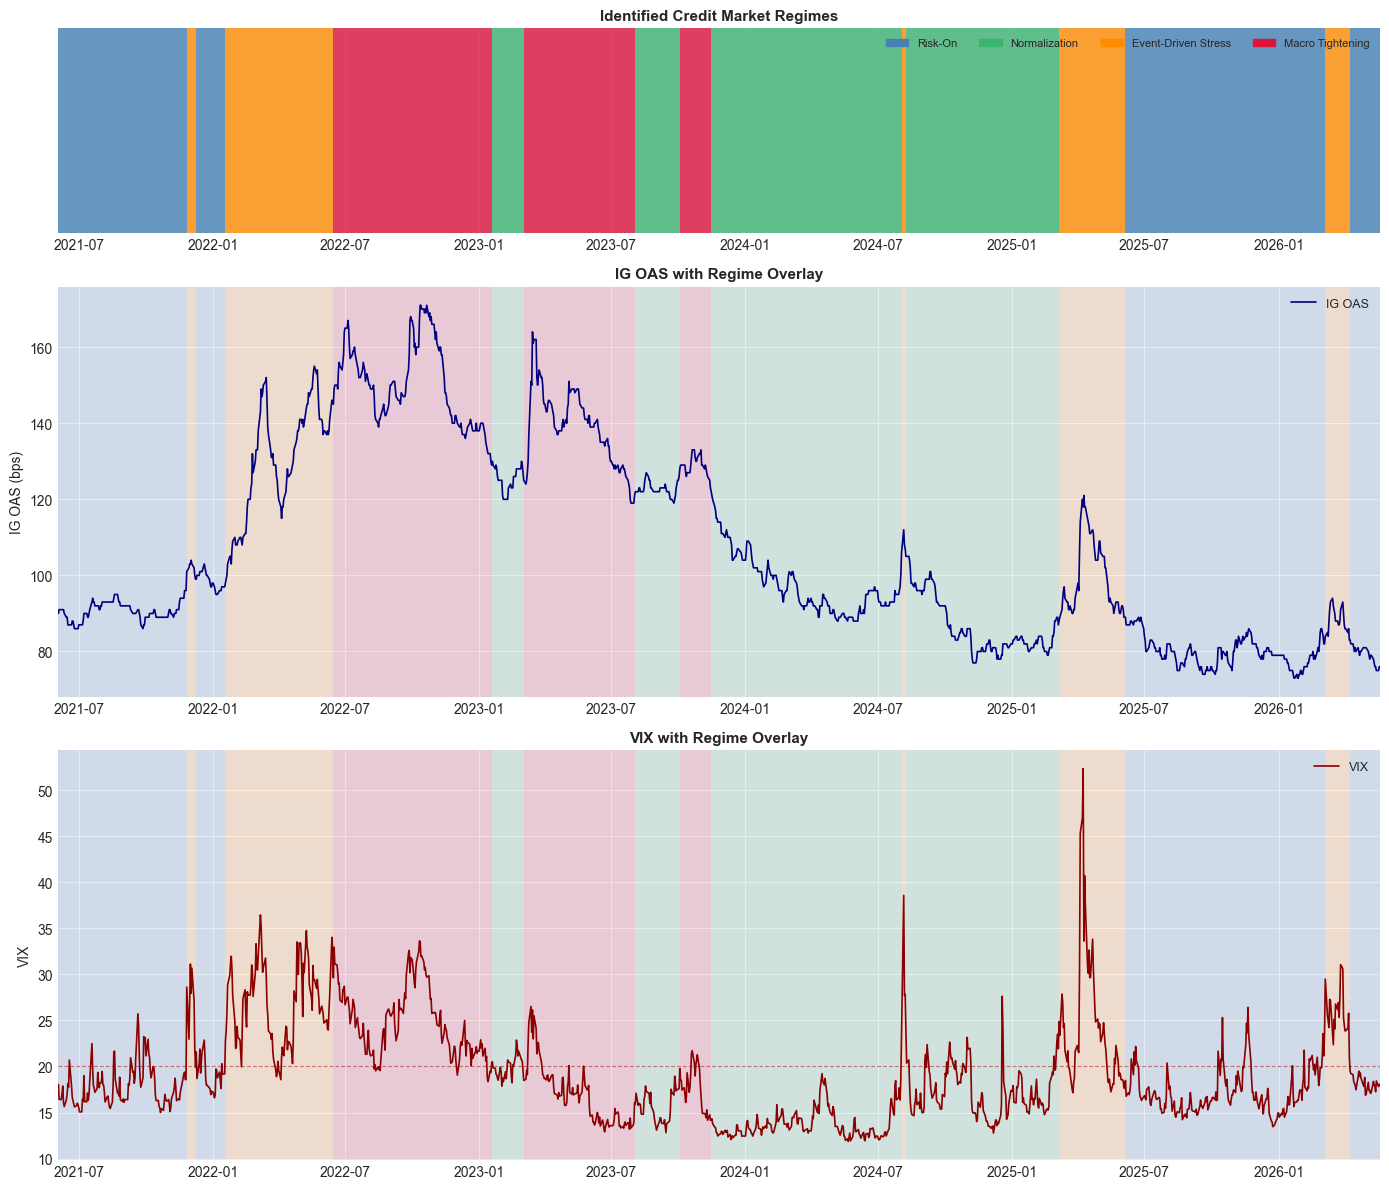

In [29]:
def shade_regimes(ax, regime_series, regime_colors, alpha=0.15):
    """
    Shade contiguous regime periods efficiently.
    """
    for label, color in regime_colors.items():
        mask = (regime_series == label).values
        indices = np.where(mask)[0]

        if len(indices) == 0:
            continue

        breaks = np.where(np.diff(indices) > 1)[0] + 1
        blocks = np.split(indices, breaks)

        for block in blocks:
            start = regime_series.index[block[0]]
            end = regime_series.index[block[-1]] + pd.Timedelta(days=1)

            ax.axvspan(
                start, end,
                alpha=alpha,
                color=color,
                linewidth=0
            )

# Align regime labels with feature index
regime_index  = features.index
regime_series = pd.Series(regime_labels,
                           index=regime_index)

fig, axes = plt.subplots(3, 1, figsize=(14, 12),
                          gridspec_kw={
                              'height_ratios': [1, 2, 2]
                          })

# --- Plot 1: Regime Timeline ---
ax1 = axes[0]
shade_regimes(ax1, regime_series, regime_colors, alpha=0.8)

ax1.set_xlim(regime_series.index.min(),
             regime_series.index.max())
ax1.set_yticks([])
ax1.set_title('Identified Credit Market Regimes',
              fontsize=11, fontweight='bold')

# Legend
patches = [
    mpatches.Patch(
        color=regime_colors[label],
        label=regime_names[label]
    )
    for label in regime_names
]
ax1.legend(handles=patches, loc='upper right',
           fontsize=8, ncol=4)

# --- Plot 2: IG OAS with regime shading ---
ax2 = axes[1]
shade_regimes(ax2, regime_series, regime_colors, alpha=0.15)

ax2.plot(df.index, df['ig_oas'],
         color='navy', linewidth=1.2,
         label='IG OAS', zorder=5)
ax2.set_title('IG OAS with Regime Overlay',
              fontsize=11, fontweight='bold')
ax2.set_ylabel('IG OAS (bps)')
ax2.set_xlim(regime_series.index.min(),
             regime_series.index.max())
ax2.legend(loc='upper right', fontsize=9)

# --- Plot 3: VIX with regime shading ---
ax3 = axes[2]
shade_regimes(ax3, regime_series, regime_colors, alpha=0.15)

ax3.plot(df.index, df['vix'],
         color='darkred', linewidth=1.2,
         label='VIX', zorder=5)
ax3.axhline(y=20, color='darkred', linestyle='--',
            linewidth=0.8, alpha=0.5)
ax3.set_title('VIX with Regime Overlay',
              fontsize=11, fontweight='bold')
ax3.set_ylabel('VIX')
ax3.set_xlim(regime_series.index.min(),
             regime_series.index.max())
ax3.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig('../data/processed/03_regime_timeline.png',
            dpi=150, bbox_inches='tight')
plt.show()

The inferred regime sequence aligns closely with major market environments over the sample period, providing strong qualitative validation of the HMM classification.

The Risk-On regime (blue) dominates the initial sample period from mid-2021 through late 2021, consistent with the low-rate, compressed-spread environment preceding the Fed tightening cycle. Risk-On conditions re-emerge from mid-2024 onward, coinciding with the soft-landing narrative and the onset of Fed rate cuts.

The Macro Tightening regime (red) captures most of the 2022 hiking cycle, characterized by persistently wide spreads, an inverted yield curve, and restrictive financial conditions. Although VIX remains elevated, it does not reach crisis levels, indicating that this regime reflects prolonged macro tightening rather than acute systemic stress.

The Normalization regime (green) represents an intermediate environment between tightening and risk-on conditions, where spreads partially compress while macro conditions gradually stabilize.

The Event-Driven Stress regime (orange) appears as short-lived volatility shocks associated with abrupt VIX spikes and temporary spread dislocations: late 2021 (Omicron variant), early 2022 (Russia-Ukraine war onset), August 2024 (Japanese yen carry trade unwind), April 2025 (tariff shock), and late 2026. Unlike the Macro Tightening regime, these episodes are brief and driven primarily by sudden repricing of market risk rather than sustained deterioration in financial conditions.

Notably, the March 2023 SVB episode is absorbed into the broader tightening regime rather than classified as a separate stress state. This reflects the HMM's inherent bias for persistent regime structures and suggests that the model interprets SVB as part of the ongoing tightening environment rather than a standalone regime shift. This is an expected trade-off because the model's average Event-Driven Stress duration of 39.8 days smooths over shorter dislocations that resolve within two to three weeks.


## Regime Distribution Analysis

To further validate the economic interpretation of each regime, we examine the distribution of key credit market variables conditional on regime assignment.

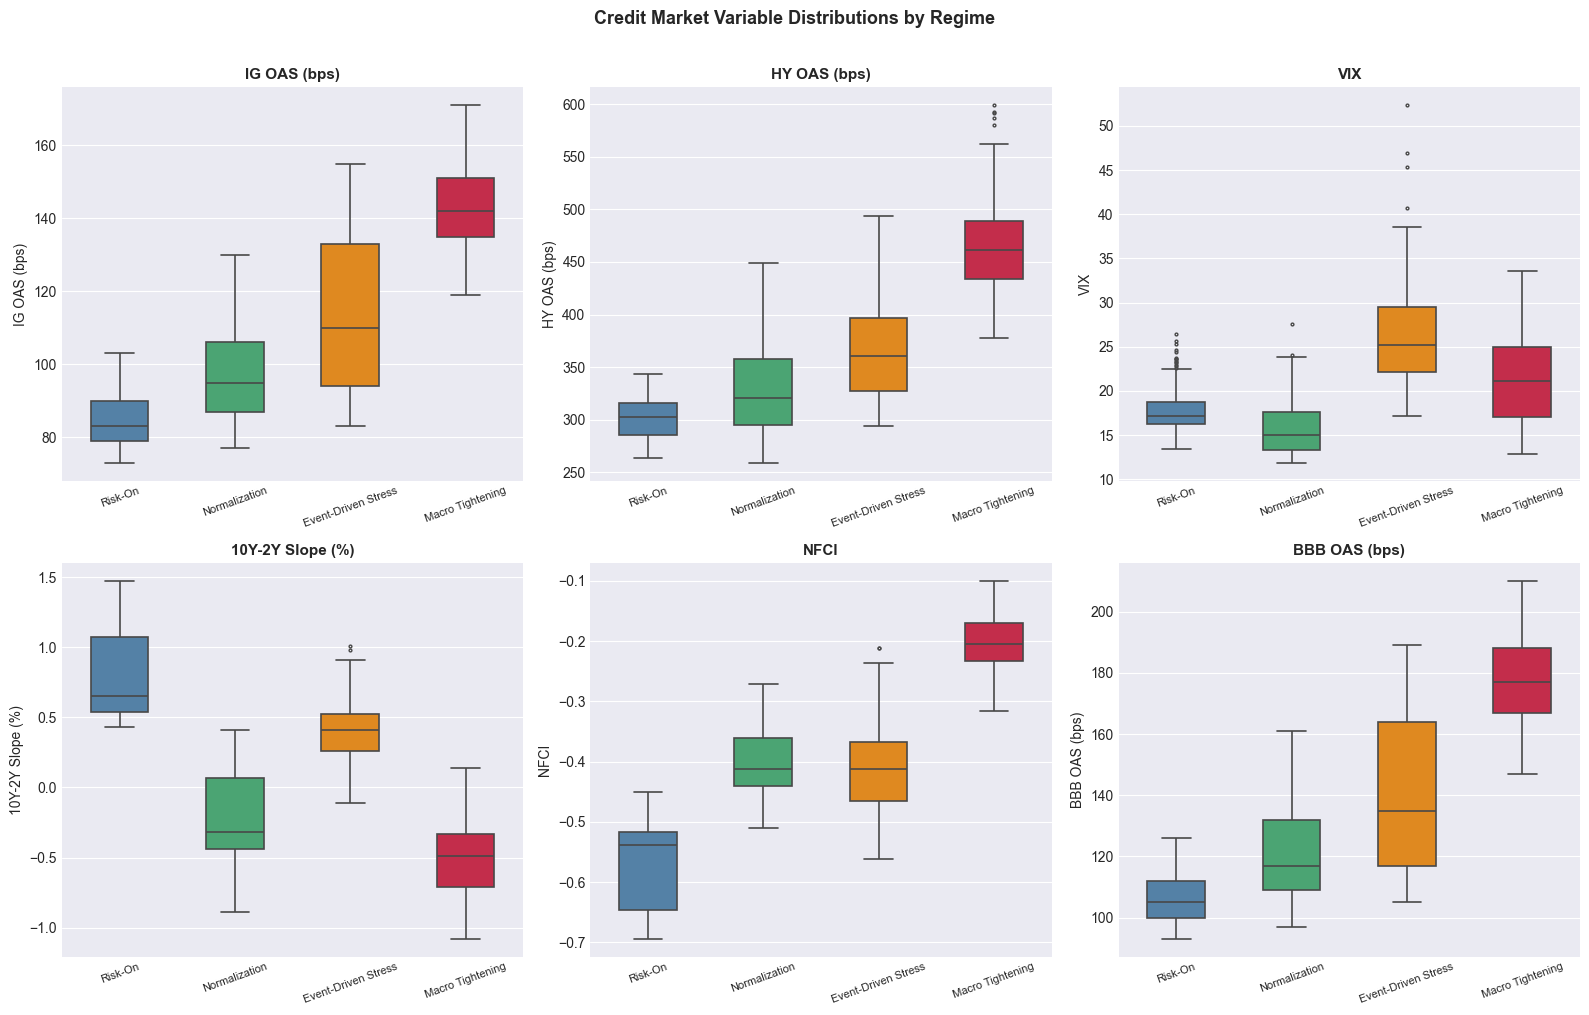

In [30]:
# Merge regime labels with main dataset
regime_df = df.copy()
regime_df = regime_df.loc[regime_series.index]
regime_df['regime'] = regime_series.values
regime_df['regime_name'] = regime_df['regime'].map(regime_names)

# Define variables to plot
plot_vars = {
    'ig_oas': 'IG OAS (bps)',
    'hy_oas': 'HY OAS (bps)',
    'vix': 'VIX',
    't10y2y': '10Y-2Y Slope (%)',
    'nfci': 'NFCI',
    'bbb_oas': 'BBB OAS (bps)',
}

regime_order = [
    'Risk-On',
    'Normalization',
    'Event-Driven Stress',
    'Macro Tightening',
]
palette = {
    'Risk-On': 'steelblue',
    'Normalization': 'mediumseagreen',
    'Event-Driven Stress': 'darkorange',
    'Macro Tightening': 'crimson',
}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for ax, (col, label) in zip(axes, plot_vars.items()):
    sns.boxplot(
        data=regime_df,
        x='regime_name',
        y=col,
        order=regime_order,
        palette=palette,
        ax=ax,
        width=0.5,
        linewidth=1.2,
        fliersize=2,
    )
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel(label)
    ax.tick_params(axis='x', rotation=20, labelsize=8)

plt.suptitle('Credit Market Variable Distributions by Regime', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../data/processed/03_regime_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

The box plots show clear distributional separation across all six variables, confirming that the four regimes represent economically distinct credit market environments rather than arbitrary statistical partitions. 

IG and BBB OAS increase monotonically from Risk-On through Macro Tightening, with limited overlap between adjacent regimes. Event-Driven Stress exhibits the widest interquartile range for IG spreads, reflecting the heterogeneous nature of short-lived volatility shocks and temporary market dislocations. HY OAS follows the same ordering but with substantially greater dispersion during Macro Tightening, where the 75th percentile exceeds 500 bps and outliers extend above 580 bps. This confirms that lower-rated credit experiences disproportionately large repricing during sustained tightening cycles. VIX provides the clearest distinction for the Event-Driven Stress regime, which displays both the highest median and the widest range, including outliers above 50. By contrast, Macro Tightening VIX levels remain only moderately elevated relative to Risk-On, reinforcing that this regime reflects restrictive financial conditions rather than acute market panic. The 10Y-2Y slope strongly separates accommodative and restrictive macro environments. Risk-On is associated with a steep positive curve, while Macro Tightening exhibits a deeply inverted curve. Normalization and Event-Driven Stress occupy intermediate positions between these two extremes. NFCI shows relatively low within-regime dispersion, particularly during Risk-On periods, indicating stable and consistently accommodative financial conditions. Macro Tightening displays the least accommodative NFCI levels throughout the sample. 

Overall, the distributions confirm that the HMM separates regimes simultaneously across spread levels, volatility, yield curve shape, and financial conditions, rather than along any single dimension alone.

Distributional statistics alone are insufficient for credit risk analysis, as regimes may differ not only in average spread levels but also in volatility, asymmetry, and tail behavior. To evaluate the risk characteristics of each regime, we analyze regime-conditional volatility and tail risk metrics for both IG and HY credit spreads.


  IG OAS — Level Metrics
                     Days  Mean (bps)  Std (bps)  P95 Level  P99 Level
Regime                                                                
Risk-On               393        84.8       7.13       97.0      101.0
Normalization         422        98.2      14.84      125.0      129.0
Event-Driven Stress   209       114.2      20.65      149.0      153.9
Macro Tightening      301       144.0      12.28      167.0      170.0

  IG OAS — Daily Change Metrics
                     Days  Ann. Vol (bps)  Mean |Chg|  P95 |Chg|  P99 |Chg|  Max 1D Chg  Skew (Chg)
Regime                                                                                             
Risk-On               393           15.12       0.635        2.0       3.00         4.0       0.360
Normalization         422           17.79       0.746        2.0       3.00         4.0       0.050
Event-Driven Stress   209           39.47       1.852        5.0       7.92        10.0       0.426
Macro Tightenin

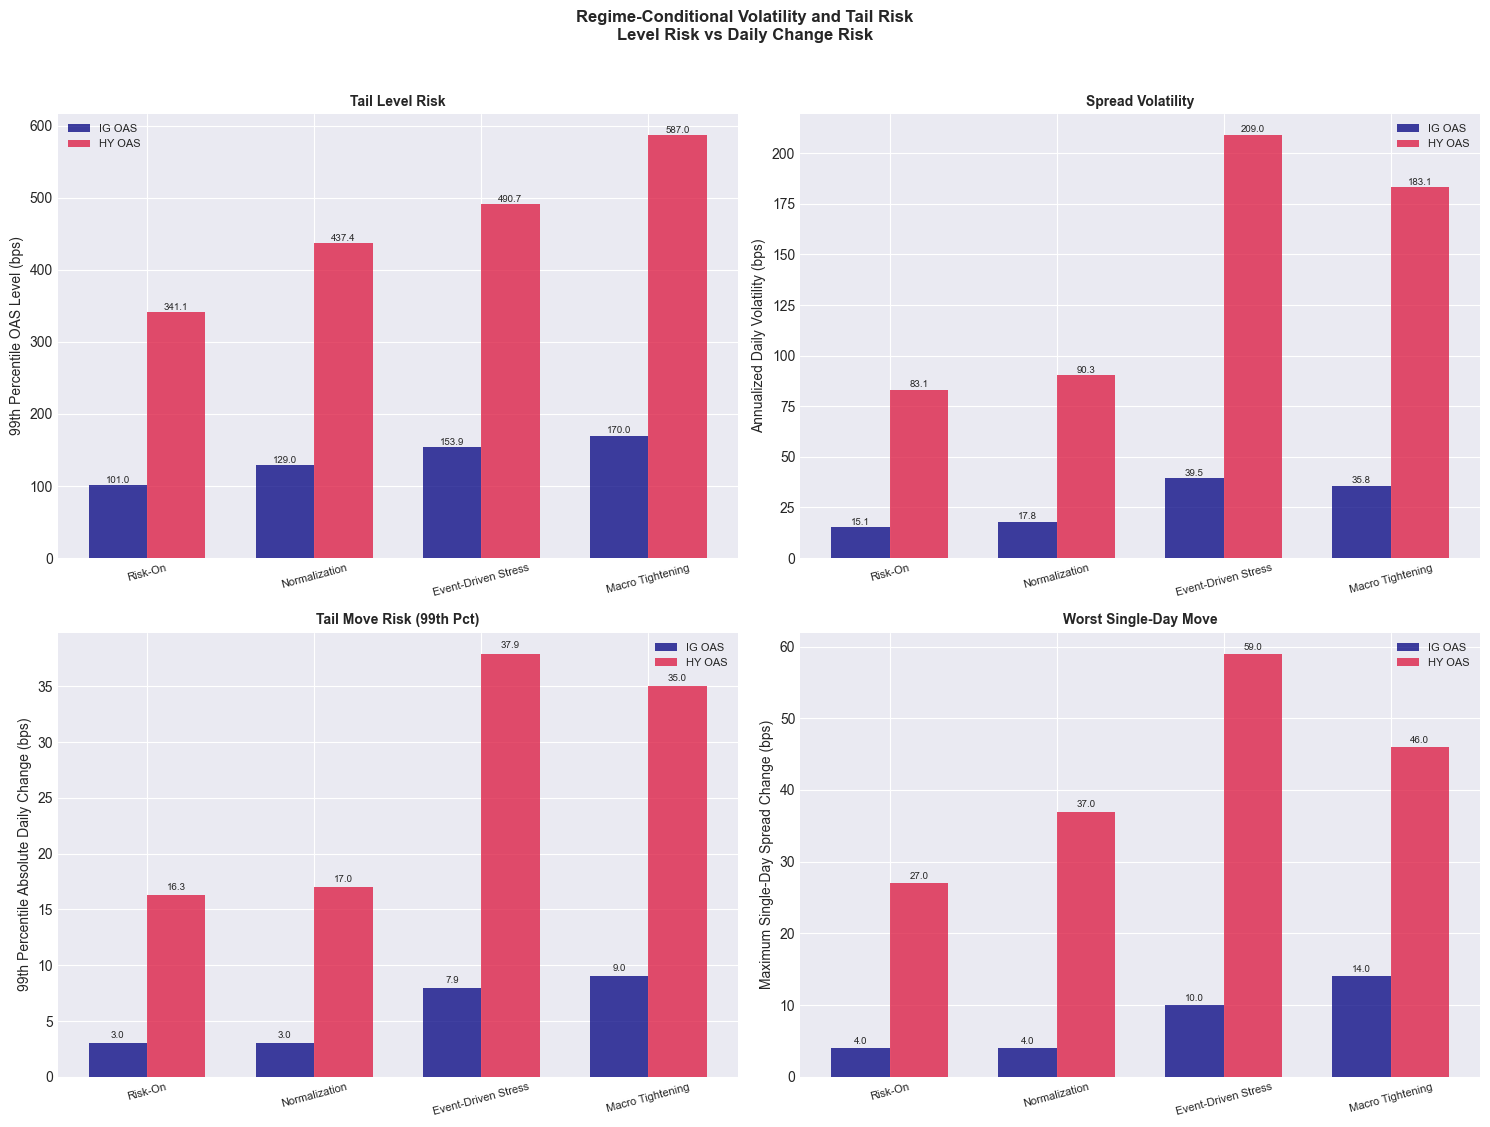

In [ ]:
risk_metrics = []

# Calculate daily changes on FULL time series first, prevents large changes at regime boundaries when regimes are non-contiguous
regime_df['ig_oas_chg'] = regime_df['ig_oas'].diff()
regime_df['hy_oas_chg'] = regime_df['hy_oas'].diff()

change_col_map = {'ig_oas': 'ig_oas_chg', 'hy_oas': 'hy_oas_chg',}


for label, name in regime_names.items():
    mask = regime_df['regime'] == label

    for col, col_label in [('ig_oas', 'IG OAS'),
                            ('hy_oas', 'HY OAS')]:
        series  = regime_df.loc[mask, col]
        changes = regime_df.loc[mask, change_col_map[col]].dropna()
        abs_changes = changes.abs()

        risk_metrics.append({
            'Regime': name,
            'Series': col_label,
            'Days': mask.sum(),
            # Level metrics
            'Mean (bps)': series.mean().round(1),
            'Std (bps)':  series.std().round(2),
            'P95 Level': series.quantile(0.95).round(1),
            'P99 Level': series.quantile(0.99).round(1),

            'Ann. Vol (bps)': (changes.std() * np.sqrt(252)).round(2),
            'Mean |Chg|': abs_changes.mean().round(3),
            'P95 |Chg|':  abs_changes.quantile(0.95).round(2),
            'P99 |Chg|': abs_changes.quantile(0.99).round(2),
            'Max 1D Chg': abs_changes.max().round(2),
            'Skew (Chg)': changes.skew().round(3),
        })

risk_df = pd.DataFrame(risk_metrics)

# Print formatted tables 
level_cols  = ['Days', 'Mean (bps)', 'Std (bps)', 'P95 Level', 'P99 Level']
change_cols = ['Days', 'Ann. Vol (bps)', 'Mean |Chg|', 'P95 |Chg|', 'P99 |Chg|', 'Max 1D Chg', 'Skew (Chg)']

for series_name in ['IG OAS', 'HY OAS']:
    subset = risk_df[risk_df['Series'] == series_name].set_index('Regime')

    print(f"\n{'='*70}")
    print(f"  {series_name} — Level Metrics")
    print(f"{'='*70}")
    print(subset[level_cols].to_string())

    print(f"\n{'='*70}")
    print(f"  {series_name} — Daily Change Metrics")
    print(f"{'='*70}")
    print(subset[change_cols].to_string())

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

plot_config = [
    ('P99 Level',    'IG OAS', 'HY OAS',
     '99th Percentile OAS Level (bps)',
     'Tail Level Risk'),
    ('Ann. Vol (bps)', 'IG OAS', 'HY OAS',
     'Annualized Daily Volatility (bps)',
     'Spread Volatility'),
    ('P99 |Chg|',    'IG OAS', 'HY OAS',
     '99th Percentile Absolute Daily Change (bps)',
     'Tail Move Risk (99th Pct)'),
    ('Max 1D Chg',   'IG OAS', 'HY OAS',
     'Maximum Single-Day Spread Change (bps)',
     'Worst Single-Day Move'),
]

x     = np.arange(len(regime_order))
width = 0.35

for ax, (metric, s1, s2, ylabel, title) in zip(
    axes.flatten(), plot_config
):
    ig_vals = [
        risk_df[
            (risk_df['Regime'] == r) &
            (risk_df['Series'] == s1)
        ][metric].values[0]
        for r in regime_order
    ]
    hy_vals = [
        risk_df[
            (risk_df['Regime'] == r) &
            (risk_df['Series'] == s2)
        ][metric].values[0]
        for r in regime_order
    ]

    bars1 = ax.bar(x - width/2, ig_vals, width, label='IG OAS', color='navy', alpha=0.75)
    bars2 = ax.bar(x + width/2, hy_vals, width, label='HY OAS', color='crimson', alpha=0.75)

    ax.set_xticks(x)
    ax.set_xticklabels(regime_order, rotation=15, fontsize=8)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8)

    for bar in list(bars1) + list(bars2):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f'{bar.get_height():.1f}',
            ha='center', va='bottom', fontsize=7
        )

plt.suptitle(
    'Regime-Conditional Volatility and Tail Risk\n'
    'Level Risk vs Daily Change Risk',
    fontsize=12, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig(
    '../data/processed/03_regime_tail_risk.png', dpi=150, bbox_inches='tight'
)
plt.show()

The regime-conditional risk metrics reveal a clear distinction between level risk and short-term volatility risk across credit market environments.

**Level risk** increases monotonically from Risk-On through Macro Tightening for both IG and HY OAS. IG 99th percentile spread levels rise from 101 bps (Risk-On) to 170 bps (Macro Tightening), while HY 99th percentile levels increase from 341 to 587 bps. HY tail levels remain consistently three to four times wider than IG equivalents, confirming the disproportionate repricing of lower-rated credit during adverse market conditions.

**Daily change risk** reveals an important distinction between the two stress regimes. Event-Driven Stress exhibits higher annualized volatility than Macro Tightening for both IG (39.5 vs 35.8 bps) and HY (209.0 vs 183.1 bps), indicating that event-driven episodes are characterized primarily by abrupt repricing and elevated jump risk rather than persistently high spread levels. This is further reflected in the largest observed HY single-day spread move, which reaches 59 bps during Event-Driven Stress.

By contrast, **Macro Tightening** produces the highest overall spread levels and the most persistent deterioration in credit conditions. Although day-to-day volatility is lower than in Event-Driven Stress, the regime exhibits sustained spread widening and elevated tail spread levels throughout the sample. Macro Tightening also generates the largest single-day IG spread move (14 bps), suggesting partial overlap in tail behavior between the two stress regimes.

**Risk-On** and **Normalization** regimes exhibit compressed spread distributions and substantially lower daily volatility. IG 99th percentile daily spread changes remain below 3–4 bps, while HY annualized volatility stays below 90 bps in both regimes, consistent with stable market functioning and orderly spread repricing.

**Skewness of daily changes** is generally positive, reflecting the asymmetric nature of credit spread movements where widening episodes tend to occur more abruptly than spread compression. The main exception is HY OAS during the Normalization regime (skew: -0.64), where negative daily changes dominate as spreads compress following prior stress episodes. Macro Tightening exhibits the highest positive skew for IG spread changes (1.75), indicating a higher frequency of large upside spread shocks during the 2022 tightening cycle.

Having identified four distinct credit regimes, we now examine correlations conditional on regime assignment to determine whether dependencies between credit spreads, volatility, financial conditions, and macro rates vary systematically across market environments.

Regime-dependent correlation structures are particularly important for stress testing and CVA analysis, where joint movements between market exposure and credit risk directly affect tail loss dynamics.

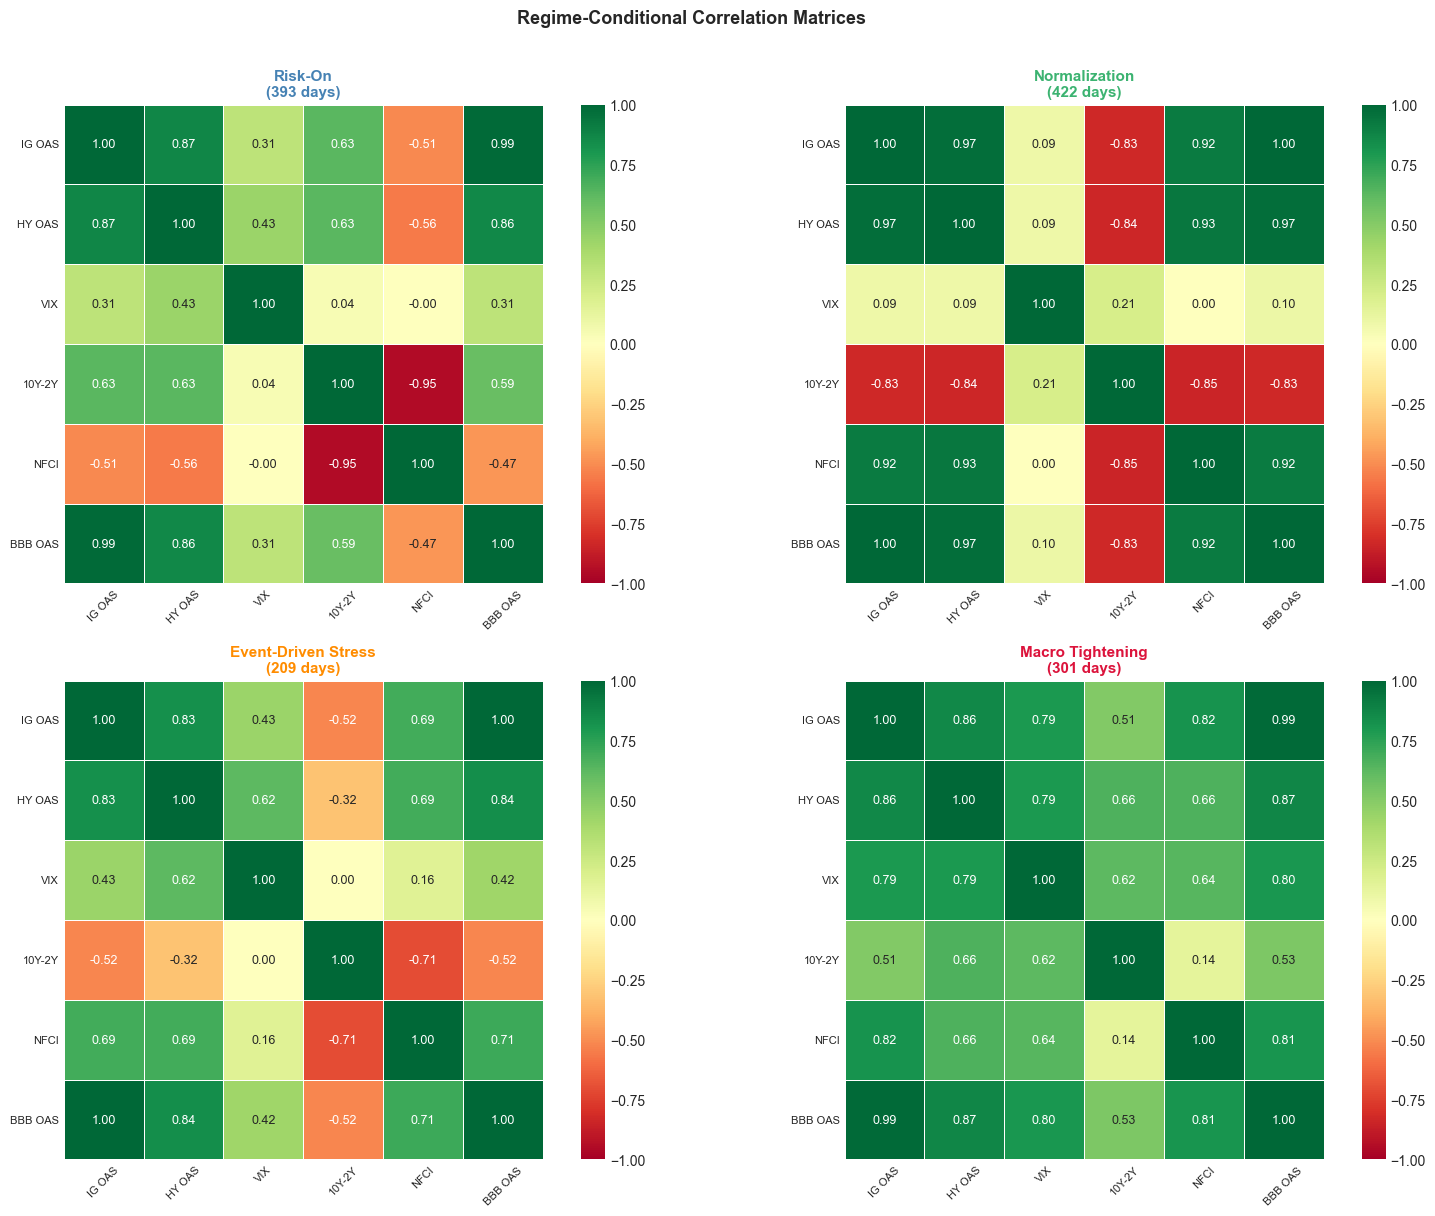

In [34]:
corr_cols = ['ig_oas', 'hy_oas', 'vix', 't10y2y', 'nfci', 'bbb_oas']

label_map_corr = {
    'ig_oas':  'IG OAS',
    'hy_oas':  'HY OAS',
    'bbb_oas': 'BBB OAS',
    'vix':     'VIX',
    't10y2y':  '10Y-2Y',
    'nfci':    'NFCI',
}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for ax, (label, name) in zip(
    axes, regime_names.items()
):
    mask   = regime_df['regime'] == label
    subset = (regime_df.loc[mask, corr_cols].rename(columns=label_map_corr))

    corr = subset.corr().round(2)

    sns.heatmap(
        corr,
        ax=ax,
        annot=True,
        fmt='.2f',
        cmap='RdYlGn',
        center=0,
        vmin=-1, vmax=1,
        square=True,
        linewidths=0.5,
        annot_kws={'size': 9}
    )
    ax.set_title(
        f'{name}\n({mask.sum()} days)',
        fontsize=11, fontweight='bold',
        color=regime_colors[label]
    )
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', rotation=0, labelsize=8)

plt.suptitle(
    'Regime-Conditional Correlation Matrices',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig( '../data/processed/03_regime_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

Regime-conditional correlations vary substantially across all four states, confirming that the HMM captures genuine structural shifts in credit market dependency rather than arbitrary data partitions.

VIX-spread correlation is highly regime-dependent. The IG-VIX correlation rises from near-zero during Normalization (0.09) to 0.43 in Event-Driven Stress and 0.79 in Macro Tightening, indicating that equity volatility becomes increasingly intertwined with credit repricing during adverse market environments.

NFCI-spread correlation also changes materially across regimes. During Risk-On, IG OAS and NFCI exhibit a negative correlation (-0.51), reflecting simultaneously compressed spreads and accommodative financial conditions. In all other regimes the relationship turns strongly positive (0.69–0.92), consistent with tighter financial conditions coinciding with spread widening.

10Y-2Y slope correlation with spreads exhibits clear sign instability across regimes: positive in Risk-On (0.63) and Macro Tightening (0.51), but strongly negative in Normalization (-0.83) and moderately negative in Event-Driven Stress (-0.52). This confirms that the relationship between yield curve shape and credit spreads is fundamentally state-dependent rather than structurally stable through time.

Within-spread correlations remain uniformly high across all regimes (IG-BBB: 0.99–1.00; IG-HY: 0.83–0.97), confirming that rating buckets continue to move broadly together regardless of market environment. The lower IG-HY correlation during Event-Driven Stress reflects the disproportionate repricing of high yield during acute volatility episodes.

Taken together, the regime-conditional correlation analysis provides a structural explanation for the time-varying factor sensitivities documented in Notebook 2 and reinforces the importance of regime-dependent dependency structures for stress testing and CVA modeling.

In [36]:
# Save regime labels
regime_output = pd.DataFrame({
    'regime':      regime_series.values,
    'regime_name': regime_series.map(regime_names).values,
}, index=regime_series.index)

regime_output.to_csv('../data/processed/regime_labels.csv')

# Save regime summary statistics
summary_rows = []

for label, name in regime_names.items():
    mask  = regime_df['regime'] == label
    raw_s = [k for k, v in label_map.items() 
             if v == label][0]
    diag  = final_model.transmat_[raw_s, raw_s]

    summary_rows.append({
        'regime': name,
        'days': mask.sum(),
        'pct': (mask.sum() / len(regime_df) * 100).round(1),
        'avg_duration': round(1 / (1 - diag), 1),
        'ig_oas_mean': regime_df.loc[mask, 'ig_oas'].mean().round(1),
        'hy_oas_mean': regime_df.loc[mask, 'hy_oas'].mean().round(1),
        'vix_mean': regime_df.loc[mask, 'vix'].mean().round(1),
        't10y2y_mean': regime_df.loc[mask, 't10y2y'].mean().round(3),
        'nfci_mean': regime_df.loc[mask, 'nfci'].mean().round(3),
        'ig_oas_vol': (regime_df.loc[mask, 'ig_oas_chg'].dropna().std() * np.sqrt(252)).round(2),
        'hy_oas_vol': (regime_df.loc[mask, 'hy_oas_chg'].dropna().std() * np.sqrt(252)).round(2),})

summary_df = pd.DataFrame(summary_rows).set_index('regime')
summary_df.to_csv('../data/processed/regime_summary.csv')

# Save transition matrix
trans_output = pd.DataFrame(
    final_model.transmat_,
    index=[regime_names[label_map[i]] 
           for i in range(4)],
    columns=[regime_names[label_map[i]] 
             for i in range(4)]
).round(4)

ordered = ['Risk-On', 'Normalization',
           'Event-Driven Stress', 
           'Macro Tightening']
trans_output = trans_output.loc[ordered, ordered]
trans_output.to_csv('../data/processed/transition_matrix.csv')

The resulting regime label series assigns each trading day to one of four market states, providing the conditioning framework for the regime-dependent hazard rate modeling in Notebook 4 and the CVA and wrong-way risk analysis in Notebook 5.